# STAR — prétraitement et explicabilité (SHAP, LIME, ICE / PDP)

Données : `data/star/STAR.csv` (Rdatasets / paquet R `AER`).
Cible : score de lecture en maternelle (`readk`) avec traitement de classe (`stark`) et covariables élève / école.
Modèle : forêt aléatoire sur variables catégorielles encodées en one-hot (interprétation locale / globale).

**Environnement :** idéalement `uv sync` à la racine puis noyau **`.venv/bin/python`**. La cellule ci‑dessous **répare automatiquement** un `.venv` incomplet (`pip install` dans le même interpréteur que Jupyter). Pour un noyau dédié dans la liste Jupyter : `uv run python -m ipykernel install --user --name=hcm-hierarchicalcausalmodels --display-name="HCM (.venv)"`.

In [ ]:
from __future__ import annotations

import importlib
import json
import subprocess
import sys
import warnings
from pathlib import Path

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _import_ok(mod: str) -> bool:
    try:
        importlib.import_module(mod)
        return True
    except ImportError:
        return False


def _ensure_shap_stack() -> None:
    if _import_ok("shap") and _import_ok("fasttreeshap_fixed") and _import_ok("lime.lime_tabular"):
        return
    specs = [
        "numpy>=2.3,<2.4",
        "llvmlite>=0.43",
        "numba>=0.62",
        "shap>=0.50",
        "fasttreeshap-fixed>=0.1.4",
        "lime>=0.2.0.1",
    ]
    print("Paquets SHAP / LIME manquants — installation via pip dans :", sys.executable)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *specs],
        check=True,
    )
    importlib.invalidate_caches()


_ensure_shap_stack()

import shap
import fasttreeshap_fixed as fts
from lime.lime_tabular import LimeTabularExplainer

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=UserWarning)


def _find_repo_root(start: Path) -> Path:
    for d in (start, *start.parents):
        if (d / "pyproject.toml").is_file():
            return d
    raise FileNotFoundError(f"pyproject.toml introuvable en remontant depuis {start}")


def _star_examples_dir(repo: Path) -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parent
    cwd = Path.cwd()
    if (cwd / "star_explainability.ipynb").is_file() or (cwd / "star_explainability.py").is_file():
        return cwd
    fallback = repo / "examples" / "STAR"
    return fallback if fallback.is_dir() else cwd


_start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
_REPO_ROOT = _find_repo_root(_start)
_STAR_DIR = _star_examples_dir(_REPO_ROOT)
_DATA_PATH = _REPO_ROOT / "data" / "star" / "STAR.csv"
_FIG_DIR = _STAR_DIR / "figures"
_FIG_DIR.mkdir(parents=True, exist_ok=True)
_RESULTS_DIR = _STAR_DIR / "results"
_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SHAP_SAMPLE = 800
LIME_N_EXPLAIN = 5
SHAP_GPU_COMPARE_ROWS = 128
FASTTREESHAP_ALGORITHM = "v2"
FASTTREESHAP_N_JOBS = -1

## Chargement et filtrage (maternelle complète)

In [ ]:
if not _DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Fichier STAR introuvable : {_DATA_PATH}. Télécharger depuis Rdatasets (AER/STAR.csv)."
    )

raw = pd.read_csv(_DATA_PATH)
cat_cols_k = [
    "gender",
    "ethnicity",
    "birth",
    "lunchk",
    "schoolk",
    "schoolidk",
    "stark",
]
target_col = "readk"

df = raw.dropna(subset=["stark", target_col]).copy()
df[cat_cols_k] = df[cat_cols_k].astype(str)

X = df[cat_cols_k]
y = df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols_k,
        ),
    ],
    remainder="drop",
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pipe = Pipeline([("preprocess", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))

DIGITS: dict[str, float | int] = {
    "n_rows_raw": int(len(raw)),
    "n_after_dropna_stark_readk": int(len(df)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_features_onehot": int(pipe.named_steps["preprocess"].transform(X_train).shape[1]),
    "r2_test": float(r2),
    "mae_test": float(mae),
    "rmse_test": float(rmse),
}

print("Métriques de prédiction (test) :")
for k in ("r2_test", "mae_test", "rmse_test"):
    print(f"  {k} = {DIGITS[k]:.4f}")
print("\nEffectifs :")
for k in ("n_rows_raw", "n_after_dropna_stark_readk", "n_train", "n_test", "n_features_onehot"):
    print(f"  {k} = {DIGITS[k]}")

Métriques de prédiction (test) :
  r2_test = 0.1939
  mae_test = 20.3791
  rmse_test = 28.5944

Effectifs :
  n_rows_raw = 11598
  n_after_dropna_stark_readk = 5789
  n_train = 4341
  n_test = 1448
  n_features_onehot = 114


## Importance par permutation (global, sur le pipeline)

In [ ]:
perm = permutation_importance(
    pipe,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_order = np.argsort(-perm.importances_mean)
perm_table = pd.DataFrame(
    {
        "feature": [cat_cols_k[i] for i in perm_order],
        "importance_mean": perm.importances_mean[perm_order],
        "importance_std": perm.importances_std[perm_order],
    }
)
display(perm_table)

DIGITS["perm_importance_stark"] = float(
    perm.importances_mean[cat_cols_k.index("stark")]
)

,feature,importance_mean,importance_std
0,schoolidk,0.191451,0.009369
1,lunchk,0.139103,0.016729
2,stark,0.043038,0.009023
3,birth,0.022773,0.006652
4,gender,0.006721,0.004454
5,ethnicity,0.006138,0.002185
6,schoolk,0.002490,0.001327


## SHAP — FastTreeSHAP (CPU, v2) et GPUTreeExplainer (si build CUDA SHAP)

[fasttreeshap-fixed](https://pypi.org/project/fasttreeshap-fixed/) : fork FastTreeSHAP compatible NumPy 2 / environnements récents (`import fasttreeshap_fixed as fts`).  
[GPUTreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.GPUTreeExplainer.html) est expérimental : il faut une installation SHAP compilée avec CUDA (`CUDA_PATH`). Sinon la cellule bascule sans erreur bloquante.

,feature,mean_abs_shap
25,cat__lunchk_free,6.357826
113,cat__stark_small,1.628470
27,cat__lunchk_non-free,1.534320
16,cat__birth_1979 Q4,1.454593
19,cat__birth_1980 Q3,1.254086
0,cat__gender_female,1.222820
1,cat__gender_male,1.153934
96,cat__schoolidk_68.0,0.948379
51,cat__schoolidk_27.0,0.859078
83,cat__schoolidk_56.0,0.686660


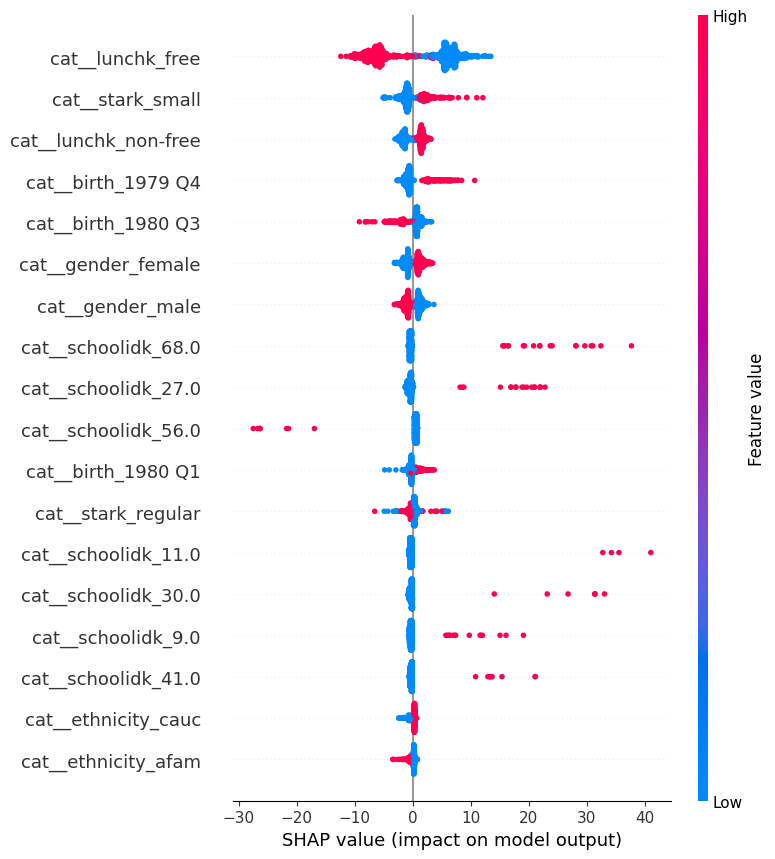

cuda extension was not built during install!
GPUTreeExplainer : indisponible avec le wheel PyPI standard (extension CUDA absente).
  Voir https://shap.readthedocs.io/ — build source avec CUDA / wheel GPU si besoin.
  Détail : cannot import name '_cext_gpu' from partially initialized module 'shap' (most likely due to a circular import) (/home/janis/hcm/hierarchicalcausalmodels/.venv/lib/python3.13/site-packages/shap/__init__.py)


In [ ]:
X_train_t = pipe.named_steps["preprocess"].transform(X_train)
X_test_t = pipe.named_steps["preprocess"].transform(X_test)
feat_names = list(pipe.named_steps["preprocess"].get_feature_names_out())

rng = np.random.default_rng(RANDOM_STATE)
n_shap = min(SHAP_SAMPLE, X_test_t.shape[0])
shap_idx = rng.choice(X_test_t.shape[0], size=n_shap, replace=False)
X_shap = np.ascontiguousarray(X_test_t[shap_idx].astype(np.float64, copy=False))
rf_fitted = pipe.named_steps["model"]

t0_fast = time.perf_counter()
ft_explainer = fts.TreeExplainer(
    rf_fitted,
    algorithm=FASTTREESHAP_ALGORITHM,
    n_jobs=FASTTREESHAP_N_JOBS,
)
shap_values_fast = ft_explainer.shap_values(X_shap)
t_fast = time.perf_counter() - t0_fast

DIGITS["shap_seconds_fasttreeshap"] = float(t_fast)
DIGITS["shap_algorithm_fasttreeshap"] = FASTTREESHAP_ALGORITHM
DIGITS["fasttreeshap_package"] = "fasttreeshap_fixed"
DIGITS["shap_n_explained"] = int(n_shap)

mean_abs = np.mean(np.abs(shap_values_fast), axis=0)
shap_rank = pd.DataFrame(
    {"feature": feat_names, "mean_abs_shap": mean_abs}
).sort_values("mean_abs_shap", ascending=False)
display(shap_rank.head(20))

DIGITS["shap_mean_abs_top1"] = float(shap_rank["mean_abs_shap"].iloc[0])
DIGITS["shap_n_background"] = int(n_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_fast,
    X_shap,
    feature_names=feat_names,
    show=False,
    max_display=18,
)
plt.tight_layout()
plt.savefig(_FIG_DIR / "shap_summary_fasttreeshap.png", dpi=150, bbox_inches="tight")
plt.show()

gpu_err_msg = ""
t_gpu = None
shap_values_gpu = None
try:
    from shap.explainers._gpu_tree import GPUTreeExplainer

    n_cmp = min(SHAP_GPU_COMPARE_ROWS, X_shap.shape[0])
    X_cmp = np.ascontiguousarray(X_shap[:n_cmp].astype(np.float32, copy=False))
    bg_size = min(256, X_train_t.shape[0])
    bg_idx = rng.choice(X_train_t.shape[0], size=bg_size, replace=False)
    X_bg = np.ascontiguousarray(X_train_t[bg_idx].astype(np.float32, copy=False))

    t0_gpu = time.perf_counter()
    gpu_explainer = GPUTreeExplainer(
        rf_fitted,
        data=X_bg,
        feature_names=feat_names,
    )
    shap_values_gpu = gpu_explainer.shap_values(X_cmp)
    t_gpu = time.perf_counter() - t0_gpu

    DIGITS["gpu_treeshap_ok"] = 1
    DIGITS["shap_seconds_gpu_treeshap"] = float(t_gpu)
    DIGITS["shap_gpu_compare_rows"] = int(n_cmp)

    sv_f = np.asarray(shap_values_fast[:n_cmp], dtype=np.float64)
    sv_g = np.asarray(shap_values_gpu, dtype=np.float64)
    DIGITS["shap_max_abs_diff_gpu_vs_fasttreeshap"] = float(np.max(np.abs(sv_f - sv_g)))

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values_gpu,
        X_cmp,
        feature_names=feat_names,
        show=False,
        max_display=18,
    )
    plt.tight_layout()
    plt.savefig(_FIG_DIR / "shap_summary_gpu_treeshap.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as exc:
    DIGITS["gpu_treeshap_ok"] = 0
    gpu_err_msg = str(exc)[:500]
    DIGITS["gpu_treeshap_error_short"] = gpu_err_msg[:200]
    em = gpu_err_msg.lower()
    if "cuda extension was not built" in em or "_cext_gpu" in em:
        DIGITS["gpu_treeshap_hint"] = "installer_shap_compile_cuda_ou_wheel_gpu"

if DIGITS.get("gpu_treeshap_ok", 0) == 0:
    print("GPUTreeExplainer : indisponible avec le wheel PyPI standard (extension CUDA absente).")
    print("  Voir https://shap.readthedocs.io/ — build source avec CUDA / wheel GPU si besoin.")
    print("  Détail :", gpu_err_msg or "(aucun message)")

## LIME (régression, quelques instances test)

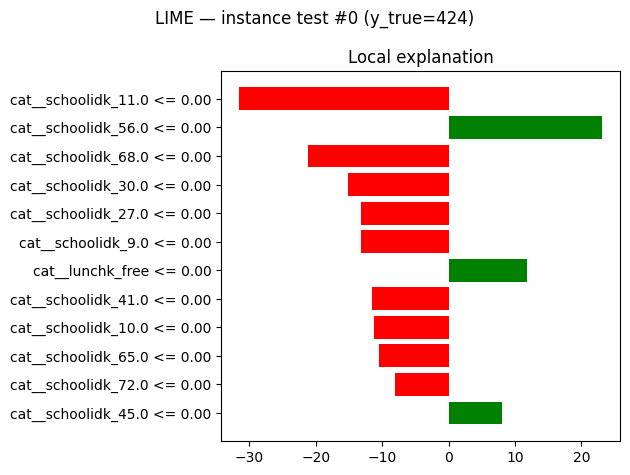

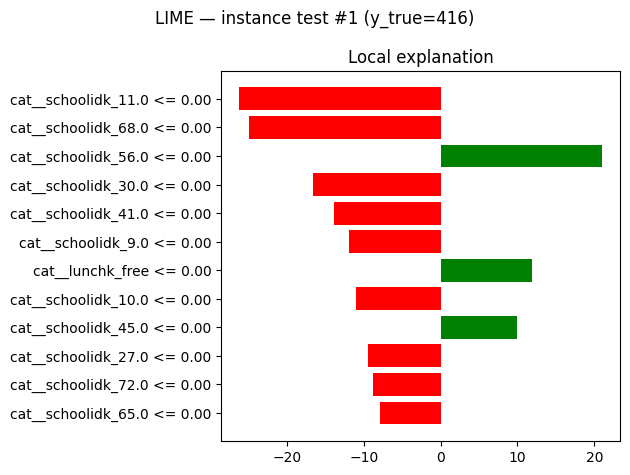

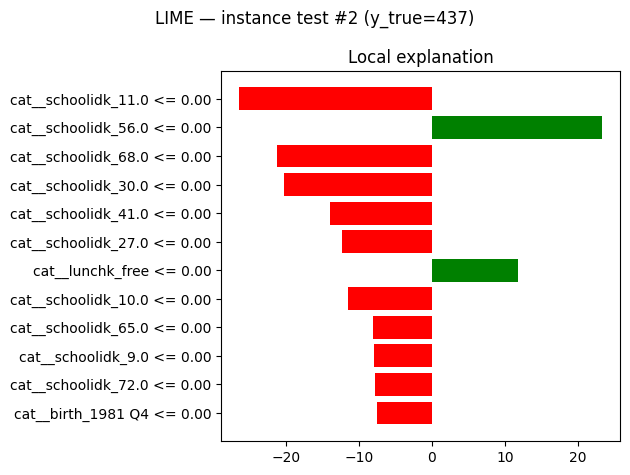

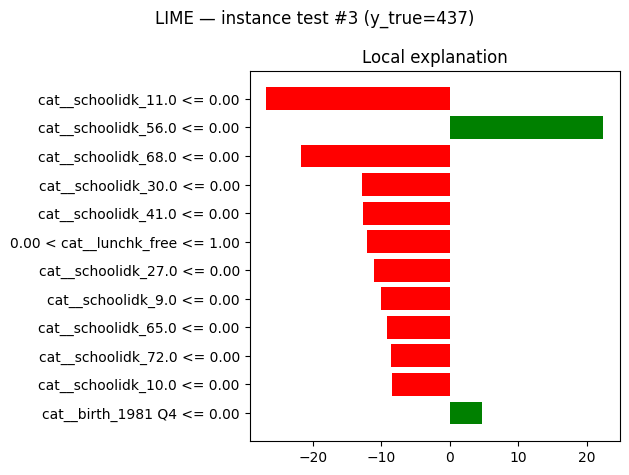

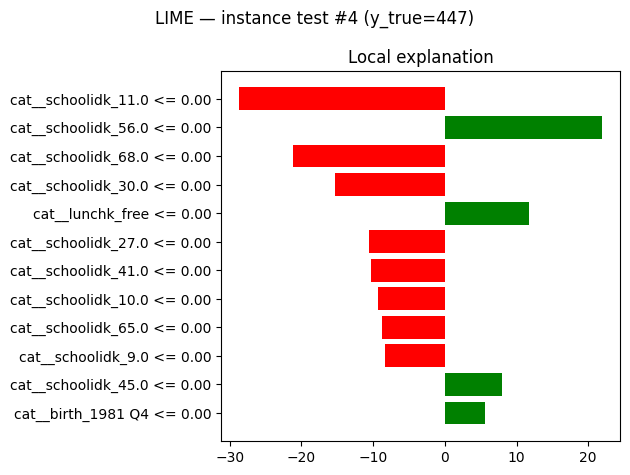

In [ ]:
train_np = X_train_t.astype(np.float64)
test_np = X_test_t.astype(np.float64)

lime_explainer = LimeTabularExplainer(
    train_np,
    feature_names=feat_names,
    mode="regression",
    discretize_continuous=True,
)


def _predict_flat(arr: np.ndarray) -> np.ndarray:
    return pipe.named_steps["model"].predict(arr)


explain_rows = list(range(min(LIME_N_EXPLAIN, test_np.shape[0])))
for i in explain_rows:
    exp = lime_explainer.explain_instance(
        test_np[i],
        _predict_flat,
        num_features=12,
        num_samples=4000,
    )
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME — instance test #{i} (y_true={y_test.iloc[i]:.0f})")
    plt.tight_layout()
    plt.savefig(_FIG_DIR / f"lime_instance_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()

## PDP (moyenne) et ICE « à la main » pour `stark`

Sklearn n’affiche pas d’ICE individuelles pour une variable catégorielle ; on trace donc la PDP officielle puis, pour un sous-échantillon du test, les prédictions quand on ne change que `stark`.

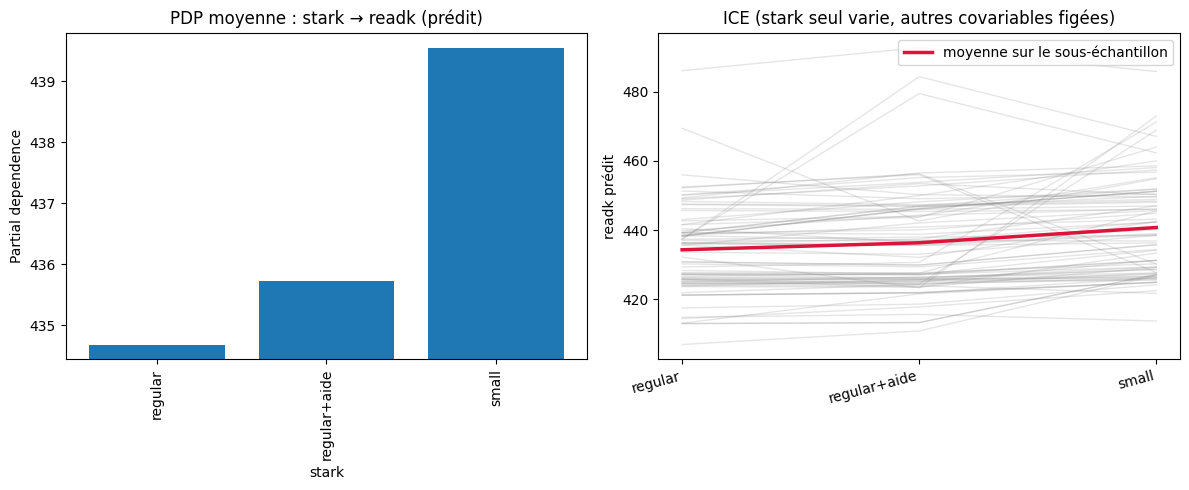

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

PartialDependenceDisplay.from_estimator(
    pipe,
    X_train,
    features=["stark"],
    categorical_features=["stark"],
    kind="average",
    ax=axes[0],
    random_state=RANDOM_STATE,
)
axes[0].set_title("PDP moyenne : stark → readk (prédit)")

stark_levels = sorted(X_train["stark"].unique())
ice_rng = np.random.default_rng(RANDOM_STATE)
ice_idx = ice_rng.choice(X_test.index, size=min(80, len(X_test)), replace=False)
x_pos = np.arange(len(stark_levels))
for idx in ice_idx:
    row = X_test.loc[[idx]].copy()
    curve = []
    for s in stark_levels:
        r = row.copy()
        r["stark"] = s
        curve.append(float(pipe.predict(r)[0]))
    axes[1].plot(x_pos, curve, color="0.5", alpha=0.2, linewidth=1)
mean_curve = []
for s in stark_levels:
    preds_s = []
    for idx in ice_idx:
        r = X_test.loc[[idx]].copy()
        r["stark"] = s
        preds_s.append(float(pipe.predict(r)[0]))
    mean_curve.append(float(np.mean(preds_s)))
for si, s in enumerate(stark_levels):
    safe = str(s).replace("+", "plus").replace(" ", "_")
    DIGITS[f"ice_mean_readk_pred_stark_{safe}"] = mean_curve[si]
if "small" in stark_levels and "regular" in stark_levels:
    DIGITS["ice_mean_diff_small_minus_regular"] = float(
        mean_curve[stark_levels.index("small")]
        - mean_curve[stark_levels.index("regular")]
    )
axes[1].plot(x_pos, mean_curve, color="crimson", linewidth=2.5, label="moyenne sur le sous-échantillon")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(stark_levels, rotation=15, ha="right")
axes[1].set_ylabel("readk prédit")
axes[1].set_title("ICE (stark seul varie, autres covariables figées)")
axes[1].legend()
plt.tight_layout()
plt.savefig(_FIG_DIR / "pdp_ice_stark.png", dpi=150, bbox_inches="tight")
plt.show()

## Synthèse numérique (`DIGITS`)

In [ ]:
pd.Series(DIGITS, name="value").to_frame()

,value
n_rows_raw,11598
n_after_dropna_stark_readk,5789
n_train,4341
n_test,1448
n_features_onehot,114
r2_test,0.193898
mae_test,20.379106
rmse_test,28.594411
perm_importance_stark,0.043038
shap_seconds_fasttreeshap,2.887511


In [ ]:
print("=== DIGITS (récap) ===")
for key, val in sorted(DIGITS.items()):
    if isinstance(val, float):
        print(f"{key}: {val:.6f}")
    else:
        print(f"{key}: {val}")

=== DIGITS (récap) ===
fasttreeshap_package: fasttreeshap_fixed
gpu_treeshap_error_short: cannot import name '_cext_gpu' from partially initialized module 'shap' (most likely due to a circular import) (/home/janis/hcm/hierarchicalcausalmodels/.venv/lib/python3.13/site-packages/shap/__init_
gpu_treeshap_hint: installer_shap_compile_cuda_ou_wheel_gpu
gpu_treeshap_ok: 0
ice_mean_diff_small_minus_regular: 6.450069
ice_mean_readk_pred_stark_regular: 434.284004
ice_mean_readk_pred_stark_regularplusaide: 436.320746
ice_mean_readk_pred_stark_small: 440.734074
mae_test: 20.379106
n_after_dropna_stark_readk: 5789
n_features_onehot: 114
n_rows_raw: 11598
n_test: 1448
n_train: 4341
perm_importance_stark: 0.043038
r2_test: 0.193898
rmse_test: 28.594411
shap_algorithm_fasttreeshap: v2
shap_mean_abs_top1: 6.357826
shap_n_background: 800
shap_n_explained: 800
shap_seconds_fasttreeshap: 2.887511


In [ ]:
_metrics_path = _RESULTS_DIR / "star_metrics.json"
_figure_paths = sorted(_FIG_DIR.glob("*.png"))
def _json_digit(v: float | int | str) -> float | int | str:
    if isinstance(v, str):
        return v
    if isinstance(v, float | np.floating):
        return float(v)
    return int(v)


_export = {
    "data_path": str(_DATA_PATH.relative_to(_REPO_ROOT)),
    "digits": {k: _json_digit(v) for k, v in DIGITS.items()},
    "figures": [str(p.relative_to(_REPO_ROOT)) for p in _figure_paths],
}
with _metrics_path.open("w", encoding="utf-8") as f:
    json.dump(_export, f, indent=2, sort_keys=True)
print(f"Résultats exportés : {_metrics_path.relative_to(_REPO_ROOT)}")

Résultats exportés : examples/STAR/results/star_metrics.json


## Références rapides

- Rdatasets STAR : [csv](https://vincentarelbundock.github.io/Rdatasets/csv/AER/STAR.csv), [doc](https://vincentarelbundock.github.io/Rdatasets/doc/AER/STAR.html)
- Figures : `shap_summary_fasttreeshap.png` ; si GPU OK, `shap_summary_gpu_treeshap.png` (sinon message dans la cellule SHAP).

--- Commentaires après coup (rédigés dans le .py, à lire hors notebook aussi) ---
- On se limite aux lignes avec stark et readk observés : c’est le sous-échantillon analysé le plus souvent en maternelle.
- La forêt sur one-hot est un proxy « boîte noire » : SHAP et LIME documentent ce modèle, pas nécessairement le vrai SCM du STAR.
- stark apparaît souvent fort en permutation / SHAP : cohérent avec l’essai randomisé, mais les scores dépendent aussi de lunchk, schoolk, schoolid (milieu).
- LIME est local : les barres changent d’une ligne à l’autre ; ne pas les lire comme un ordre global unique.
- PDP/ICE pour stark agrègent sur la distribution des autres covariables ; utile pour un effet marginal moyen dans ce modèle prédictif.
- Pour allier au papier HCM : unité = école (schoolidk), sous-unité = élève ; ici le pipeline est plat (sans plaque explicite), mais les digits et figures servent de préliminaires avant un graphe hiérarchique.
- Écart entre permutation importance (souvent schoolidk en tête) et rang SHAP sur one-hot : la forêt utilise des interactions fines par école ; SHAP décompose sur chaque colonne binaire, d’où des niveaux schoolidk visibles dans le top.
- Les courbes ICE « stark seul varie » sont conditionnelles au modèle RF + one-hot, pas à l’ATE expérimental du STAR ; elles servent d’audit de dépendance prédictive.
- En non interactif, `plt.show()` peut ne rien afficher ; les PNG sous `examples/STAR/figures/` restent l’artefact principal.
- fasttreeshap-fixed (v2, n_jobs=-1) remplace le paquet `fasttreeshap` LinkedIn, incompatible NumPy 2 ; GPUTreeExplainer exige un build SHAP+Cuda (sinon DIGITS.gpu_treeshap_ok=0).